# Feature Engineering Diagnostics for `meta_dataset.csv`

This notebook evaluates whether engineered features are **informative** and **diverse enough** by checking:
- Data quality (missing values, duplicates, constants)
- Variance and near-zero variance features
- Redundancy (high correlation pairs)
- Effective dimensionality (PCA variance coverage)
- Separation against target (`mut_found`) using Cohen's d

You will get a final health report and practical recommendations.

In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [27]:
# Locate dataset relative to this notebook
candidate_paths = [
    Path('meta_dataset.csv'),
    Path('./meta_dataset.csv'),
    Path('output/meta_dataset.csv')
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError('Could not find meta_dataset.csv next to notebook or in output/.')

df = pd.read_csv(csv_path)
print(f'Loaded: {csv_path.resolve()}')
print(f'Shape: {df.shape}')
df.head(3)

Loaded: C:\Users\HQCHEJUN\Downloads\ddPCR_ML\flowsom\output\meta_dataset.csv
Shape: (41, 30)


,n_droplets,ch1_std,ch1_iqr,ch1_cv,ch1_skew,ch1_kurt,ch1_bimodality,ch1_log_std,ch1_log_skew,ch1_outlier_frac,ch1_kde_peaks,ch2_std,ch2_iqr,ch2_cv,ch2_skew,ch2_kurt,ch2_bimodality,ch2_log_std,ch2_log_skew,ch2_outlier_frac,ch2_kde_peaks,ch1_ch2_corr,dataset,best_n_clusters,best_xdim,best_ydim,best_rlen,best_silhouette,clear_clustering,mut_found
0,18087,99.144387,128.843506,0.039794,0.452678,0.774211,0.319250,0.039516,0.303371,0.005418,1,196.451783,88.539551,0.153685,7.445395,67.773158,0.797391,0.108866,5.328935,0.015536,1,0.400112,220905_MIP-096_TRT19_TA387_20220905_131631_249...,2,6.0,8.0,22.0,0.888189,True,False
1,16842,140.645776,155.152405,0.055939,-0.805718,1.131096,0.399212,0.057500,-1.024953,0.010450,1,86.690902,102.480469,0.068521,-0.431026,0.648307,0.325023,0.070004,-0.694092,0.006472,1,0.717233,220905_MIP-096_TRT19_TA387_20220905_131631_249...,1,NaN,NaN,NaN,NaN,True,False
2,19772,64.803978,85.785461,0.049809,0.133840,2.775012,0.176262,0.050257,-0.957992,0.004248,1,542.503947,212.003540,0.206001,2.032502,2.672057,0.904622,0.175225,1.843012,0.010115,2,0.256737,220809_MIP097PS_TRT043_TA388_20220908_114051_4...,2,14.0,8.0,72.0,0.877223,True,False


In [28]:
# Basic schema and target checks
print('Dtypes:')
display(df.dtypes.to_frame('dtype').T)

target_col = 'mut_found' if 'mut_found' in df.columns else None
id_like = {'dataset'}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_cols if c not in id_like]

print(f'Numeric features considered: {len(numeric_features)}')
print('First 10 numeric features:', numeric_features[:10])

if target_col is not None:
    print('Target distribution:')
    print(df[target_col].value_counts(dropna=False))
else:
    print('No target column named mut_found found; target-based checks will be skipped.')

Dtypes:


,n_droplets,ch1_std,ch1_iqr,ch1_cv,ch1_skew,ch1_kurt,ch1_bimodality,ch1_log_std,ch1_log_skew,ch1_outlier_frac,ch1_kde_peaks,ch2_std,ch2_iqr,ch2_cv,ch2_skew,ch2_kurt,ch2_bimodality,ch2_log_std,ch2_log_skew,ch2_outlier_frac,ch2_kde_peaks,ch1_ch2_corr,dataset,best_n_clusters,best_xdim,best_ydim,best_rlen,best_silhouette,clear_clustering,mut_found
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,object,int64,float64,float64,float64,float64,bool,bool


Numeric features considered: 27
First 10 numeric features: ['n_droplets', 'ch1_std', 'ch1_iqr', 'ch1_cv', 'ch1_skew', 'ch1_kurt', 'ch1_bimodality', 'ch1_log_std', 'ch1_log_skew', 'ch1_outlier_frac']
Target distribution:
mut_found
False    28
True     13
Name: count, dtype: int64


In [29]:
# Data quality report
missing_ratio = df[numeric_features].isna().mean().sort_values(ascending=False)
n_duplicates = int(df.duplicated().sum())
constant_features = [c for c in numeric_features if df[c].nunique(dropna=True) <= 1]

quality_report = pd.DataFrame({
    'missing_ratio': missing_ratio,
    'nunique': [df[c].nunique(dropna=True) for c in missing_ratio.index],
})

print(f'Duplicate rows: {n_duplicates}')
print(f'Constant numeric features: {len(constant_features)}')
display(quality_report.head(10))

Duplicate rows: 0
Constant numeric features: 0


,missing_ratio,nunique
best_rlen,0.170732,28
best_ydim,0.170732,6
best_xdim,0.170732,6
best_silhouette,0.170732,34
ch1_skew,0.000000,41
ch1_kurt,0.000000,41
ch1_bimodality,0.000000,41
ch1_cv,0.000000,41
n_droplets,0.000000,41
ch1_std,0.000000,41


In [30]:
# Variance and near-zero variance analysis
eps = 1e-12
stds = df[numeric_features].std(ddof=0)
means = df[numeric_features].mean().abs()
cv_like = stds / (means + eps)

near_zero_std_threshold = 1e-3
near_zero_cv_threshold = 1e-3
near_zero_features = sorted(set(stds[stds < near_zero_std_threshold].index) | set(cv_like[cv_like < near_zero_cv_threshold].index))

var_report = pd.DataFrame({
    'std': stds,
    'abs_mean': means,
    'cv_like': cv_like
}).sort_values('std')

print(f'Near-zero variance features: {len(near_zero_features)}')
display(var_report.head(12))

Near-zero variance features: 0


,std,abs_mean,cv_like
ch1_outlier_frac,0.008668,0.007146,1.213016
ch2_outlier_frac,0.018863,0.010116,1.864752
best_silhouette,0.080235,0.874484,0.091751
ch1_log_std,0.119258,0.109522,1.088901
ch1_cv,0.201208,0.151671,1.326613
ch2_log_std,0.215423,0.328043,0.656692
ch2_cv,0.232016,0.335699,0.691142
ch1_bimodality,0.254754,0.413549,0.616019
ch2_bimodality,0.261228,0.789680,0.330802
ch1_ch2_corr,0.262174,0.480211,0.545955


In [31]:
# Redundancy: highly correlated feature pairs
X = df[numeric_features].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

corr_threshold = 0.95
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'abs_corr'})
    .query('abs_corr >= @corr_threshold')
    .sort_values('abs_corr', ascending=False)
)

print(f'Highly correlated pairs (|r| >= {corr_threshold}): {len(high_corr_pairs)}')
display(high_corr_pairs.head(20))

Highly correlated pairs (|r| >= 0.95): 1


,feature_a,feature_b,abs_corr
276,ch2_skew,ch2_log_skew,0.95098


PCs needed for 90% variance: 11
PCs needed for 95% variance: 14
Total numeric features: 27


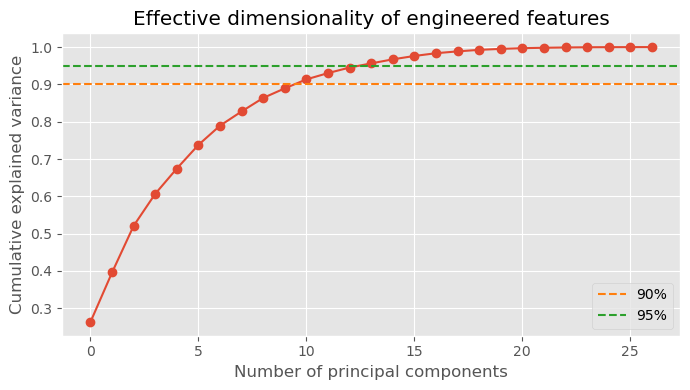

In [32]:
# Effective dimensionality via PCA on standardized data (numpy SVD)
X_std = (X - X.mean()) / (X.std(ddof=0) + 1e-12)
X_std = X_std.fillna(0.0)

_, svals, _ = np.linalg.svd(X_std.values, full_matrices=False)
eigvals = (svals ** 2) / max(1, (X_std.shape[0] - 1))
explained = eigvals / eigvals.sum()
cum_explained = np.cumsum(explained)

pc90 = int(np.searchsorted(cum_explained, 0.90) + 1)
pc95 = int(np.searchsorted(cum_explained, 0.95) + 1)

print(f'PCs needed for 90% variance: {pc90}')
print(f'PCs needed for 95% variance: {pc95}')
print(f'Total numeric features: {len(numeric_features)}')

plt.figure(figsize=(7, 4))
plt.plot(cum_explained, marker='o')
plt.axhline(0.90, color='tab:orange', linestyle='--', label='90%')
plt.axhline(0.95, color='tab:green', linestyle='--', label='95%')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('Effective dimensionality of engineered features')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# Target separability check with Cohen's d (if mut_found exists)
def cohens_d(x0, x1):
    x0 = np.asarray(x0, dtype=float)
    x1 = np.asarray(x1, dtype=float)
    x0 = x0[np.isfinite(x0)]
    x1 = x1[np.isfinite(x1)]
    if len(x0) < 2 or len(x1) < 2:
        return np.nan
    m0, m1 = x0.mean(), x1.mean()
    v0, v1 = x0.var(ddof=1), x1.var(ddof=1)
    pooled = np.sqrt(((len(x0)-1)*v0 + (len(x1)-1)*v1) / (len(x0)+len(x1)-2 + 1e-12))
    if pooled < 1e-12:
        return 0.0
    return (m1 - m0) / pooled

sep_report = None
if target_col is not None:
    y = df[target_col].astype(bool)
    d_values = {}
    for c in numeric_features:
        d_values[c] = cohens_d(df.loc[~y, c], df.loc[y, c])

    sep_report = pd.DataFrame({'cohens_d': pd.Series(d_values)}).dropna()
    sep_report['abs_d'] = sep_report['cohens_d'].abs()
    sep_report = sep_report.sort_values('abs_d', ascending=False)

    print('Top features by target separation (|Cohen\'s d|):')
    display(sep_report.head(15))
else:
    print('Skipped target separation: mut_found not found.')

Top features by target separation (|Cohen's d|):


,cohens_d,abs_d
ch1_log_skew,2.009390,2.009390
best_n_clusters,1.861452,1.861452
ch1_skew,1.328330,1.328330
ch1_bimodality,1.156939,1.156939
ch1_std,1.141981,1.141981
ch1_cv,1.072171,1.072171
ch1_log_std,0.840486,0.840486
ch2_log_std,0.819737,0.819737
ch2_bimodality,0.775400,0.775400
ch1_kurt,0.694631,0.694631


In [34]:
# Diversity summary and verdict
n_features = len(numeric_features)
n_constant = len(constant_features)
n_near_zero = len(near_zero_features)
n_high_corr_pairs = len(high_corr_pairs)

pct_constant = 100 * n_constant / max(1, n_features)
pct_near_zero = 100 * n_near_zero / max(1, n_features)
redundancy_pressure = 100 * n_high_corr_pairs / max(1, n_features * (n_features - 1) / 2)

top_missing = missing_ratio.max() if len(missing_ratio) else 0
good_missing = top_missing < 0.20
good_constant = pct_constant < 10
good_near_zero = pct_near_zero < 20
good_corr = redundancy_pressure < 10
good_dimensionality = (pc95 / max(1, n_features)) > 0.35

checks = pd.Series({
    'Low missingness (max < 20%)': good_missing,
    'Few constant features (<10%)': good_constant,
    'Few near-zero variance features (<20%)': good_near_zero,
    'Manageable high-corr pressure (<10% pairs)': good_corr,
    'Sufficient intrinsic dimensionality (PC95 ratio > 35%)': good_dimensionality,
})

score = int(checks.sum())
if score >= 4:
    verdict = 'GOOD: feature engineering appears informative and diverse enough for modeling.'
elif score >= 3:
    verdict = 'MODERATE: usable features, but some redundancy or low-variance risk exists.'
else:
    verdict = 'WEAK: feature set likely needs redesign (redundancy/low diversity/quality issues).'

summary = pd.DataFrame({
    'metric': [
        'n_features', 'n_constant', 'n_near_zero', 'high_corr_pairs',
        'max_missing_ratio', 'pc90', 'pc95', 'pc95_to_n_features'
    ],
    'value': [
        n_features, n_constant, n_near_zero, n_high_corr_pairs,
        float(top_missing), pc90, pc95, float(pc95 / max(1, n_features))
    ]
})

print('=== FEATURE HEALTH CHECKS ===')
display(checks.to_frame('pass'))
print('')
print('=== SUMMARY ===')
display(summary)
print('')
print('=== VERDICT ===')
print(verdict)

if sep_report is not None and not sep_report.empty:
    strong_sep = (sep_report['abs_d'] >= 0.8).sum()
    moderate_sep = ((sep_report['abs_d'] >= 0.5) & (sep_report['abs_d'] < 0.8)).sum()
    print('')
    print(f'Target-separating features: strong={strong_sep}, moderate={moderate_sep}')

=== FEATURE HEALTH CHECKS ===


,pass
Low missingness (max < 20%),True
Few constant features (<10%),True
Few near-zero variance features (<20%),True
Manageable high-corr pressure (<10% pairs),True
Sufficient intrinsic dimensionality (PC95 ratio > 35%),True



=== SUMMARY ===


,metric,value
0,n_features,27.000000
1,n_constant,0.000000
2,n_near_zero,0.000000
3,high_corr_pairs,1.000000
4,max_missing_ratio,0.170732
5,pc90,11.000000
6,pc95,14.000000
7,pc95_to_n_features,0.518519



=== VERDICT ===
GOOD: feature engineering appears informative and diverse enough for modeling.

Target-separating features: strong=8, moderate=7


## How to interpret quickly
- If `high_corr_pairs` is high, remove one feature from each highly correlated pair.
- If `pc95_to_n_features` is very low, many features are redundant.
- If many features have near-zero variance, engineer more dynamic statistics.
- If few features separate `mut_found`, add biologically meaningful interaction or nonlinear transforms.

## Class Balance Summary
This section summarizes target balance for `best_n_clusters` and `mut_found`.

Interpretation guideline:
- `imbalance_ratio = max_class_count / min_class_count`
- <= 2.0: good balance
- 2.0 to 5.0: moderate imbalance
- > 5.0: strong imbalance (use class weights or re-sampling)

In [35]:
def balance_summary(series, name):
    s = series.dropna()
    counts = s.value_counts().sort_index()
    perc = (counts / counts.sum() * 100).round(2)
    out = pd.DataFrame({
        'count': counts,
        'percent': perc
    })

    if len(counts) <= 1:
        ratio = np.nan
        label = 'not enough classes'
    else:
        ratio = float(counts.max() / counts.min())
        if ratio <= 2.0:
            label = 'good balance'
        elif ratio <= 5.0:
            label = 'moderate imbalance'
        else:
            label = 'strong imbalance'

    print(f'=== {name} ===')
    print(f'n_classes: {len(counts)}')
    print(f'imbalance_ratio (max/min): {ratio if np.isfinite(ratio) else "NA"}')
    print(f'interpretation: {label}')
    display(out)
    print('')


if 'best_n_clusters' in df.columns:
    balance_summary(df['best_n_clusters'], 'best_n_clusters')
else:
    print('Column best_n_clusters not found.')

if 'mut_found' in df.columns:
    balance_summary(df['mut_found'], 'mut_found')
else:
    print('Column mut_found not found.')

=== best_n_clusters ===
n_classes: 4
imbalance_ratio (max/min): 2.0
interpretation: good balance


,count,percent
best_n_clusters,,
1,7,17.07
2,9,21.95
3,11,26.83
4,14,34.15



=== mut_found ===
n_classes: 2
imbalance_ratio (max/min): 2.1538461538461537
interpretation: moderate imbalance


,count,percent
mut_found,,
False,28,68.29
True,13,31.71


## Target Impact Benchmark (Integrated from temp_target_feature_impact.py)
This section benchmarks how strongly engineered features affect each target.

Targets included:
- Classification: best_n_clusters
- Regression: best_xdim, best_ydim, best_rlen

In [36]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.dummy import DummyClassifier, DummyRegressor

exclude = {'dataset', 'clear_clustering', 'mut_found'}
feature_cols = [
    c for c in df.columns
    if c not in exclude and not c.startswith('best_') and pd.api.types.is_numeric_dtype(df[c])
]

rows = []

# Classification target
target = 'best_n_clusters'
sub = df[feature_cols + [target]].dropna()
X = sub[feature_cols]
y = sub[target].astype(int)
class_counts = y.value_counts()
min_class = int(class_counts.min()) if len(class_counts) else 0
cv_n = max(2, min(5, min_class)) if min_class >= 2 else 2

clf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced')
dummy_clf = DummyClassifier(strategy='most_frequent')

cv = StratifiedKFold(n_splits=cv_n, shuffle=True, random_state=42)
model_scores = cross_val_score(clf, X, y, cv=cv, scoring='f1_macro')
baseline_scores = cross_val_score(dummy_clf, X, y, cv=cv, scoring='f1_macro')

rows.append({
    'target': target,
    'task': 'classification',
    'n_samples': len(sub),
    'metric': 'macro_f1',
    'model_mean': model_scores.mean(),
    'model_std': model_scores.std(),
    'baseline_mean': baseline_scores.mean(),
    'gain': model_scores.mean() - baseline_scores.mean(),
})

# Regression targets (best_silhouette intentionally excluded)
for target in ['best_xdim', 'best_ydim', 'best_rlen']:
    sub = df[feature_cols + [target]].dropna()
    X = sub[feature_cols]
    y = sub[target].astype(float)
    n = len(sub)
    cv_n = max(2, min(5, n))
    cv = KFold(n_splits=cv_n, shuffle=True, random_state=42)

    reg = RandomForestRegressor(n_estimators=500, random_state=42)
    dummy_reg = DummyRegressor(strategy='mean')

    model_scores = cross_val_score(reg, X, y, cv=cv, scoring='r2')
    baseline_scores = cross_val_score(dummy_reg, X, y, cv=cv, scoring='r2')

    rows.append({
        'target': target,
        'task': 'regression',
        'n_samples': n,
        'metric': 'r2',
        'model_mean': model_scores.mean(),
        'model_std': model_scores.std(),
        'baseline_mean': baseline_scores.mean(),
        'gain': model_scores.mean() - baseline_scores.mean(),
    })

impact_res = pd.DataFrame(rows).sort_values('gain', ascending=False)
print('Feature columns used:', len(feature_cols))
print('')
display(impact_res)

Feature columns used: 22



,target,task,n_samples,metric,model_mean,model_std,baseline_mean,gain
0,best_n_clusters,classification,41,macro_f1,0.630238,0.219918,0.126818,0.503420
1,best_xdim,regression,34,r2,-0.346277,0.201808,-0.201758,-0.144519
3,best_rlen,regression,34,r2,-0.616679,0.467483,-0.135039,-0.481640
2,best_ydim,regression,34,r2,-0.999106,1.086308,-0.451091,-0.548015


In [37]:
# Per-cluster regression impact: for each best_n_clusters group, benchmark features vs mean-baseline on xdim/ydim/rlen
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.dummy import DummyRegressor

group_col = 'best_n_clusters'
reg_targets = ['best_xdim', 'best_ydim', 'best_rlen']

exclude = {'dataset', 'clear_clustering', 'mut_found'}
feature_cols = [
    c for c in df.columns
    if c not in exclude and not c.startswith('best_') and pd.api.types.is_numeric_dtype(df[c])
]

grouped_rows = []

if group_col not in df.columns:
    print(f'Column {group_col} not found; skipping per-cluster analysis.')
else:
    for k, gdf in df.groupby(group_col):
        for target in reg_targets:
            sub = gdf[feature_cols + [target]].dropna()
            n = len(sub)
            y = sub[target].astype(float) if n else pd.Series(dtype=float)

            row = {
                'best_n_clusters': int(k),
                'target': target,
                'n_samples': n,
                'target_std': float(y.std(ddof=0)) if n else np.nan,
            }

            if n < 4 or y.nunique() < 2:
                row.update({
                    'model_mean_r2': np.nan,
                    'model_std_r2': np.nan,
                    'baseline_mean_r2': np.nan,
                    'gain': np.nan,
                    'note': 'insufficient samples or no variance',
                })
                grouped_rows.append(row)
                continue

            X = sub[feature_cols]
            cv_n = max(2, min(5, n))
            cv = KFold(n_splits=cv_n, shuffle=True, random_state=42)

            reg = RandomForestRegressor(n_estimators=500, random_state=42)
            dummy_reg = DummyRegressor(strategy='mean')

            model_scores = cross_val_score(reg, X, y, cv=cv, scoring='r2')
            baseline_scores = cross_val_score(dummy_reg, X, y, cv=cv, scoring='r2')

            row.update({
                'model_mean_r2': model_scores.mean(),
                'model_std_r2': model_scores.std(),
                'baseline_mean_r2': baseline_scores.mean(),
                'gain': model_scores.mean() - baseline_scores.mean(),
                'note': '',
            })
            grouped_rows.append(row)

    grouped_impact = pd.DataFrame(grouped_rows).sort_values(['target', 'best_n_clusters'])
    print('Per-cluster regression impact (R2 vs mean-baseline):')
    display(grouped_impact)


c:\Users\HQCHEJUN\AppData\Local\miniforge3\envs\learn_python\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\HQCHEJUN\AppData\Local\miniforge3\envs\learn_python\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\HQCHEJUN\AppData\Local\miniforge3\envs\learn_python\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\HQCHEJUN\AppData\Local\miniforge3\envs\learn_python\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\HQCHEJUN\AppData\Lo

Per-cluster regression impact (R2 vs mean-baseline):


,best_n_clusters,target,n_samples,target_std,model_mean_r2,model_std_r2,baseline_mean_r2,gain,note
2,1,best_rlen,0,NaN,NaN,NaN,NaN,NaN,insufficient samples or no variance
5,2,best_rlen,9,19.924549,NaN,NaN,NaN,NaN,
8,3,best_rlen,11,26.413745,-24.262513,48.228166,-4.985612,-19.276901,
11,4,best_rlen,14,31.665342,-1.147132,1.547209,-0.901939,-0.245193,
0,1,best_xdim,0,NaN,NaN,NaN,NaN,NaN,insufficient samples or no variance
3,2,best_xdim,9,3.861810,NaN,NaN,NaN,NaN,
6,3,best_xdim,11,3.391774,-0.442440,0.484507,-0.586967,0.144527,
9,4,best_xdim,14,3.260775,-0.307495,0.788139,-0.488098,0.180603,
1,1,best_ydim,0,NaN,NaN,NaN,NaN,NaN,insufficient samples or no variance
4,2,best_ydim,9,3.046958,NaN,NaN,NaN,NaN,
